AQI FORECAST INTELLIGENCE
Historical AQI Values: [280, 320, 355, 390, 430]
Predicted Next 3 Days AQI: [399, 394, 396]

FORECAST DETAILS
  Day  Predicted AQI  Category                    Health Advisory
Day 1            399 Very Poor Avoid outdoor exposure if possible
Day 2            394 Very Poor Avoid outdoor exposure if possible
Day 3            396 Very Poor Avoid outdoor exposure if possible


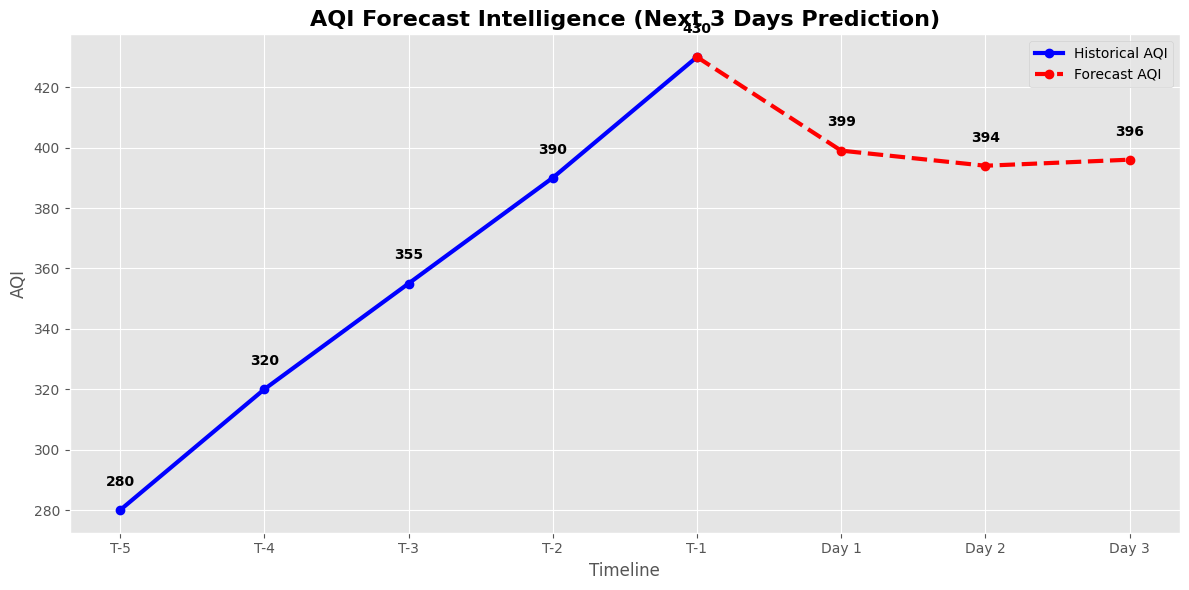


FORECAST EXECUTIVE INSIGHTS
Highest predicted AQI: 399
Highest risk category: Very Poor
Forecast suggests very poor air quality.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('ggplot')

# ==========================================
# AQI CATEGORY CLASSIFIER
# ==========================================

def classify_aqi(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

# ==========================================
# HEALTH ADVISORY
# ==========================================

def health_advisory(aqi):
    if aqi <= 50:
        return "Safe outdoor conditions"
    elif aqi <= 100:
        return "Generally acceptable air quality"
    elif aqi <= 200:
        return "Sensitive groups should reduce outdoor exposure"
    elif aqi <= 300:
        return "Limit outdoor activities"
    elif aqi <= 400:
        return "Avoid outdoor exposure if possible"
    else:
        return "Emergency health risk. Stay indoors."

# ==========================================
# SIMPLE FORECAST MODEL
# ==========================================

def predict_next_days(history, days=3):
    predictions = []
    current = history.copy()

    for _ in range(days):
        pred = (
            current[-1] * 0.45 +
            current[-2] * 0.30 +
            current[-3] * 0.15 +
            current[-4] * 0.07 +
            current[-5] * 0.03
        )

        # slight random variation
        pred += np.random.randint(-10, 10)

        pred = max(0, min(500, pred))

        predictions.append(round(pred))
        current.append(pred)

    return predictions

# ==========================================
# INPUT AQI HISTORY
# ==========================================

aqi_history = [280, 320, 355, 390, 430]

# you can change above values manually

# ==========================================
# FORECAST
# ==========================================

forecast = predict_next_days(aqi_history, 3)

print("="*70)
print("AQI FORECAST INTELLIGENCE")
print("="*70)

print("Historical AQI Values:", aqi_history)
print("Predicted Next 3 Days AQI:", forecast)

# ==========================================
# FORECAST TABLE
# ==========================================

forecast_df = pd.DataFrame({
    'Day': ['Day 1', 'Day 2', 'Day 3'],
    'Predicted AQI': forecast,
    'Category': [classify_aqi(x) for x in forecast],
    'Health Advisory': [health_advisory(x) for x in forecast]
})

print("\nFORECAST DETAILS")
print("="*70)
print(forecast_df.to_string(index=False))

# ==========================================
# VISUALIZATION
# ==========================================

historical_days = ['T-5', 'T-4', 'T-3', 'T-2', 'T-1']
future_days = ['Day 1', 'Day 2', 'Day 3']

plt.figure(figsize=(12,6))

plt.plot(
    historical_days,
    aqi_history,
    marker='o',
    linewidth=3,
    color='blue',
    label='Historical AQI'
)

combined_x = ['T-1'] + future_days
combined_y = [aqi_history[-1]] + forecast

plt.plot(
    combined_x,
    combined_y,
    marker='o',
    linewidth=3,
    linestyle='dashed',
    color='red',
    label='Forecast AQI'
)

for i, val in enumerate(aqi_history):
    plt.text(i, val+8, str(val), ha='center', fontweight='bold')

for i, val in enumerate(combined_y):
    x_pos = len(historical_days)-1 + i
    if i > 0:
        plt.text(x_pos, val+8, str(val), ha='center', fontweight='bold')

plt.title(
    "AQI Forecast Intelligence (Next 3 Days Prediction)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Timeline")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# EXECUTIVE SUMMARY
# ==========================================

max_forecast = max(forecast)

print("\n" + "="*70)
print("FORECAST EXECUTIVE INSIGHTS")
print("="*70)

print(f"Highest predicted AQI: {max_forecast}")
print(f"Highest risk category: {classify_aqi(max_forecast)}")

if max_forecast > 400:
    print("Forecast suggests severe pollution conditions ahead.")
elif max_forecast > 300:
    print("Forecast suggests very poor air quality.")
else:
    print("Forecast indicates moderate pollution trend.")

print("="*70)